# TIPE


## Requirements and Settings

In [1]:
import os
import uuid
import cv2
from PIL import Image, ImageDraw

## Dataset load

In [3]:
import tensorflow as tf
import json
import numpy as np
import matplotlib.pyplot as plt

In [4]:
images = tf.data.Dataset.list_files('data\\images\\*.jpg', shuffle=False)

In [5]:
def load_image(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img

In [6]:
images = images.map(load_image)

In [7]:
# images.as_numpy_iterator().next()

In [8]:
image_generator = images.batch(4).as_numpy_iterator()

In [9]:
plot_images = image_generator.next()

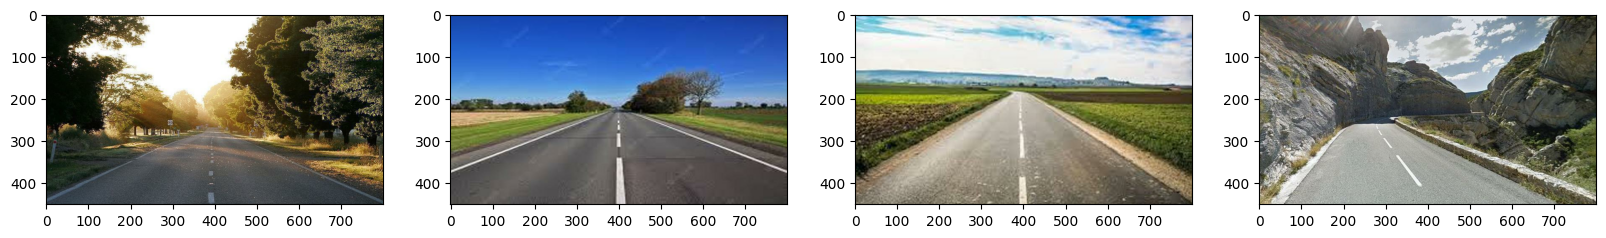

In [10]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, image in enumerate(plot_images):
    ax[idx].imshow(image)
plt.show()

## Data Split

In [11]:
# Here split images into three folders: train / test / val
# Need enough amount of images
# 70% for train, 15% for each test and val

In [12]:
# for folder in  ['train', 'test', 'val']:
#     for file in os.listdir(os.path.join('data', folder, 'images')):
#         filename = file.split('.')[0]+'.json'
#         existing_filepath = os.path.join('data', 'labels', filename)
#         if os.path.exists(existing_filepath):
#             new_filepath = os.path.join('data',folder,'labels',filename)
#             os.replace(existing_filepath, new_filepath)

## Augmentation

In [13]:
import albumentations as alb

In [14]:
augmentor = alb.Compose([alb.RandomCrop(width=400, height=225), alb.HorizontalFlip(p=0.5), alb.RandomBrightnessContrast(p=0.2), alb.RandomGamma(p=0.2), alb.RGBShift(p=0.2)])

In [15]:
image = plt.imread(os.path.join('data', 'images', '18c31b86-b2d6-11ed-9fa7-0242ac1c000c.jpg'))
mask = plt.imread(os.path.join('data', 'masks', '18c31b86-b2d6-11ed-9fa7-0242ac1c000c.png'))

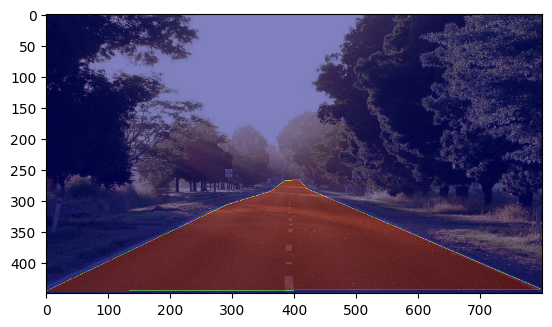

In [16]:
plt.imshow(image)
plt.imshow(mask, cmap='jet', alpha=0.5)

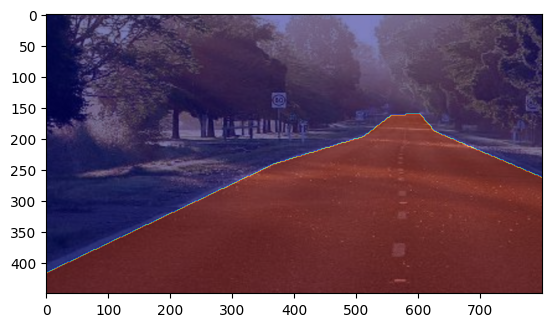

In [17]:
transformed = augmentor(image=image, mask=mask)
newim=cv2.resize(transformed['image'], dsize=(800,450))
newmask=cv2.resize(transformed['mask'], dsize=(800,450))
plt.imshow(newim)
plt.imshow(newmask, cmap='jet', alpha=0.5)
plt.imsave('test.png', newmask, cmap='gray')

In [18]:
# Code pour augmenter toutes les images n fois (utiliser comme nom: "uuid.i.ext")

## Datasets

In [19]:
train_images = tf.data.Dataset.list_files('data\\images\\*.jpg', shuffle=False)
train_images = train_images.map(load_image)
train_images = train_images.map(lambda x: tf.image.resize(x, (256,456)))
train_images = train_images.map(lambda x: x/255)

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


In [20]:
# do the same for tests and validations

In [21]:
# train_images.as_numpy_iterator().next()

In [22]:
train_masks = tf.data.Dataset.list_files('data\\masks\\*.png', shuffle=False)
train_masks = train_masks.map(load_image)
train_masks = train_masks.map(lambda x: tf.image.resize(x, (256,456)))
train_masks = train_masks.map(lambda x: x//255)

In [23]:
# do the same for test and validations

In [24]:
len(train_images),len(train_masks)

(4, 4)

In [37]:
train = tf.data.Dataset.zip((train_images, train_masks))
train = train.shuffle(3*len(train_images))
train = train.batch(8)
train = train.prefetch(4)

In [26]:
# do the same for test and validations

In [38]:
train.as_numpy_iterator().next()[0].shape

(4, 256, 456, 3)

In [39]:
data_samples = train.as_numpy_iterator()

In [40]:
res = data_samples.next()

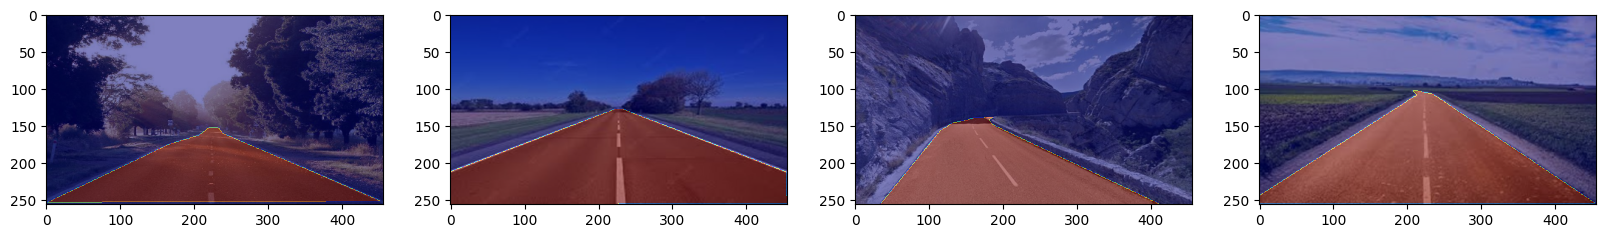

In [41]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4):
    image=res[0][idx]
    mask=res[1][idx]
    ax[idx].imshow(image)
    ax[idx].imshow(mask, cmap='jet', alpha=0.5)
plt.show()

## Deep Learning

In [31]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Conv3D, Dense, GlobalMaxPooling2D, GlobalMaxPooling3D, UpSampling2D, MaxPool2D, MaxPooling2D, Dropout, Concatenate

In [ ]:
def build_model():
    input_shape = (256, 456, 3)

    # Define the input layer
    inputs = Input(input_shape)

    # Encoder
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D((2, 2))(conv1)

    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D((2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D((2, 2))(conv3)

    # Decoder
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(256, (3, 3), activation='relu', padding='same')(conv4)
    drop4 = Dropout(0.5)(conv4)
    up5 = UpSampling2D((2, 2))(drop4)
    up5 = Conv2D(128, (3, 3), activation='relu', padding='same')(up5)
    concat5 = Concatenate()([conv3, up5])

    conv5 = Conv2D(128, (3, 3), activation='relu', padding='same')(concat5)
    conv5 = Conv2D(128, (3, 3), activation='relu', padding='same')(conv5)
    up6 = UpSampling2D((2, 2))(conv5)
    up6 = Conv2D(64, (3, 3), activation='relu', padding='same')(up6)
    concat6 = Concatenate()([conv2, up6])

    conv6 = Conv2D(64, (3, 3), activation='relu', padding='same')(concat6)
    conv6 = Conv2D(64, (3, 3), activation='relu', padding='same')(conv6)
    up7 = UpSampling2D((2, 2))(conv6)
    up7 = Conv2D(32, (3, 3), activation='relu', padding='same')(up7)
    concat7 = Concatenate()([conv1, up7])

    conv7 = Conv2D(32, (3, 3), activation='relu', padding='same')(concat7)
    conv7 = Conv2D(32, (3, 3), activation='relu', padding='same')(conv7)

    # Output layer
    output = Conv2D(1, (1, 1), activation='sigmoid')(conv7)
    
    # Create the model
    model = Model(inputs=inputs, outputs=output)
    return model

In [33]:
roadmodel = build_model()

In [48]:
# roadmodel.summary()

In [62]:
X, Y = train.as_numpy_iterator().next()

In [64]:
masks = roadmodel.predict(X)

1/1 [==============================] - 1s 573ms/step


## Losses and Optimizers

In [59]:
from tensorflow.keras.optimizers.legacy import Adam

In [57]:
batches_per_epoch = len(train)
lr_decay = (1./0.75 -1)/batches_per_epoch

In [60]:
optimizer = Adam(learning_rate=0.0001, decay=lr_decay)

In [65]:
loss_fn = tf.keras.losses.BinaryCrossentropy()

In [77]:
loss_fn(Y, masks).numpy()

0.7140955

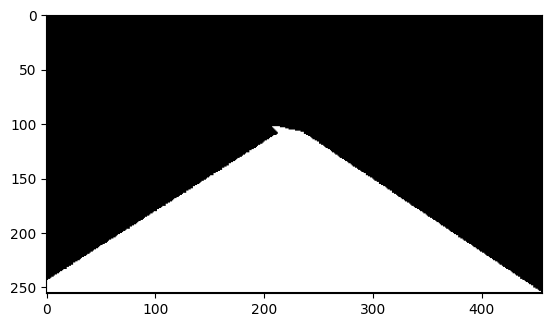

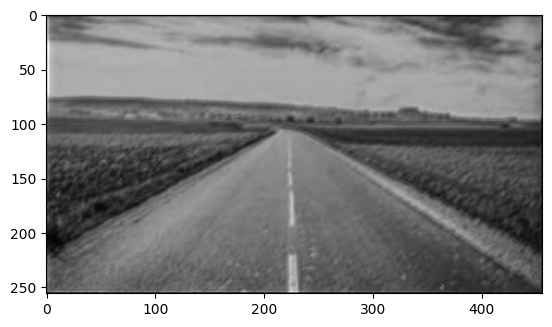

In [73]:
plt.figure(0)
plt.imshow(Y[1], cmap="gray")
plt.figure(1)
plt.imshow(masks[1], cmap="gray")
plt.show()

## Training

In [79]:
roadmodel.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

In [80]:
logdir='logs'

In [81]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [125]:
hist = roadmodel.fit(train, epochs=40, callbacks=[tensorboard_callback])

Epoch 1/40
1/1 [==============================] - 3s 3s/step - loss: 0.6533 - accuracy: 0.7366
Epoch 2/40
1/1 [==============================] - 3s 3s/step - loss: 0.6524 - accuracy: 0.7366
Epoch 3/40
1/1 [==============================] - 3s 3s/step - loss: 0.6514 - accuracy: 0.7366
Epoch 4/40
1/1 [==============================] - 3s 3s/step - loss: 0.6504 - accuracy: 0.7365
Epoch 5/40
1/1 [==============================] - 3s 3s/step - loss: 0.6495 - accuracy: 0.7365
Epoch 6/40
1/1 [==============================] - 3s 3s/step - loss: 0.6485 - accuracy: 0.7364
Epoch 7/40
1/1 [==============================] - 3s 3s/step - loss: 0.6475 - accuracy: 0.7364
Epoch 8/40
1/1 [==============================] - 3s 3s/step - loss: 0.6465 - accuracy: 0.7365
Epoch 9/40
1/1 [==============================] - 3s 3s/step - loss: 0.6455 - accuracy: 0.7364
Epoch 10/40
1/1 [==============================] - 3s 3s/step - loss: 0.6445 - accuracy: 0.7364
Epoch 11/40
1/1 [==============================] 

In [84]:
hist.history

{'loss': [0.7140188813209534,
  0.7063881158828735,
  0.7006217837333679,
  0.6961122751235962,
  0.6927996277809143,
  0.6900821328163147,
  0.687627911567688,
  0.6854637265205383,
  0.6835799217224121,
  0.6819018721580505,
  0.6804175972938538,
  0.679040253162384,
  0.677699625492096,
  0.6764932870864868,
  0.6754710078239441,
  0.6745358109474182,
  0.6736483573913574,
  0.6727681159973145,
  0.671951174736023,
  0.6711310148239136,
  0.6703528761863708,
  0.669561505317688,
  0.6687539219856262,
  0.6679177284240723,
  0.6671348810195923,
  0.6663727164268494,
  0.6656418442726135,
  0.6648876667022705,
  0.6641173362731934,
  0.6633087992668152,
  0.6624348759651184,
  0.6615657210350037,
  0.6606429815292358,
  0.6597434878349304,
  0.6588170528411865,
  0.6579166054725647,
  0.657025933265686,
  0.6561048030853271,
  0.6551180481910706,
  0.6542271375656128],
 'accuracy': [0.2619757354259491,
  0.2652352452278137,
  0.2927502989768982,
  0.37166768312454224,
  0.541673064231

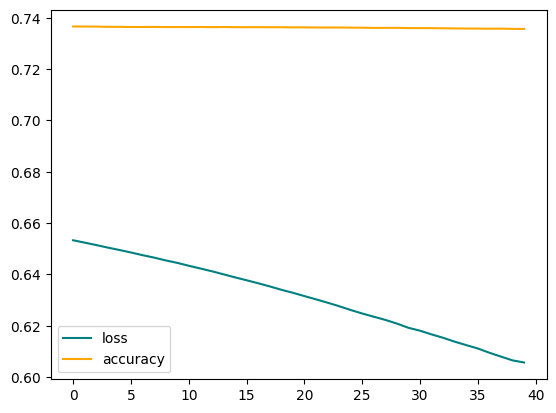

In [126]:
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['accuracy'], color='orange', label='accuracy')
plt.legend()
plt.show()

In [148]:
test_sample = train.as_numpy_iterator().next() #replace with test instead of train

In [149]:
yhat = roadmodel.predict(test_sample[0])

1/1 [==============================] - 1s 514ms/step


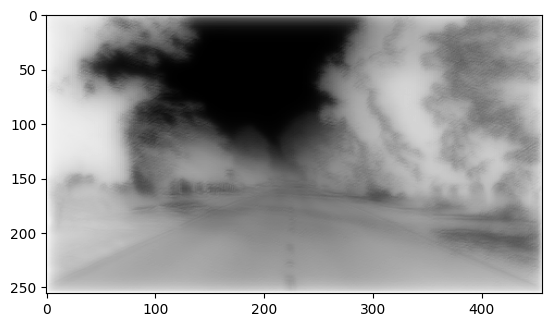

In [150]:
plt.imshow(yhat[0], cmap='gray')

In [124]:
type(yhat[0])

numpy.ndarray